# классификация

In [189]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdulwadood11220/netflix-customer-churn-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Aleggg\.cache\kagglehub\datasets\abdulwadood11220\netflix-customer-churn-dataset\versions\1


In [190]:
import pandas as pd
import numpy as np

In [191]:
df = pd.read_csv(r'C:\Users\Aleggg\.cache\kagglehub\datasets\abdulwadood11220\netflix-customer-churn-dataset\versions\1\netflix_customer_churn.csv')

In [192]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [193]:
df.dtypes

customer_id                object
age                         int64
gender                     object
subscription_type          object
watch_hours               float64
last_login_days             int64
region                     object
device                     object
monthly_fee               float64
churned                     int64
payment_method             object
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre             object
dtype: object

In [194]:
df = df.drop('customer_id', axis=1)

In [195]:
from sklearn.preprocessing import LabelEncoder

columns = ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']

le = LabelEncoder()
for i in columns:
    df[i] = le.fit_transform(df[i])

In [196]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,2,0,14.73,29,0,3,8.99,1,3,1,0.49,0
1,47,2,2,0.70,19,2,2,13.99,1,3,5,0.03,6
2,27,0,2,16.32,10,1,3,13.99,0,1,2,1.48,3
3,53,2,1,4.51,12,4,3,17.99,1,1,2,0.35,4
4,56,2,2,1.89,13,0,2,13.99,1,1,2,0.13,0


In [197]:
df.columns

Index(['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days',
       'region', 'device', 'monthly_fee', 'churned', 'payment_method',
       'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre'],
      dtype='object')

In [198]:
def iqr(colums):
    q1 = np.quantile(colums, 0.25) #или же нахождения медианты нижних значений (первую четверть)
    q3 = np.quantile(colums, 0.75) #по такому же принципу что и прошлое но там уже верхние значения

    IQR = q3 - q1
    #определяем выбросы
    down = q1 - 1.5 * IQR
    up = q3 + 1.5 * IQR
    #up, down
    blowout = (colums < down) | (colums > up)

    return blowout, down, up

In [199]:
col = ['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days',
       'region', 'device', 'monthly_fee', 'churned', 'payment_method',
       'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre']

for i in col:
    blowout, down, up = iqr(df[i])
    print(i, blowout.sum())

age 0
gender 0
subscription_type 0
watch_hours 238
last_login_days 0
region 0
device 0
monthly_fee 0
churned 0
payment_method 0
number_of_profiles 0
avg_watch_time_per_day 549
favorite_genre 0


In [200]:
df['watch_hours'] = np.log1p(df['watch_hours'])
df['avg_watch_time_per_day'] = np.log1p(df['avg_watch_time_per_day'])

In [201]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,2,0,2.755570,29,0,3,8.99,1,3,1,0.398776,0
1,47,2,2,0.530628,19,2,2,13.99,1,3,5,0.029559,6
2,27,0,2,2.851862,10,1,3,13.99,0,1,2,0.908259,3
3,53,2,1,1.706565,12,4,3,17.99,1,1,2,0.300105,4
4,56,2,2,1.061257,13,0,2,13.99,1,1,2,0.122218,0


In [202]:
X = df.drop('churned', axis=1)
y = df['churned']

<Axes: >

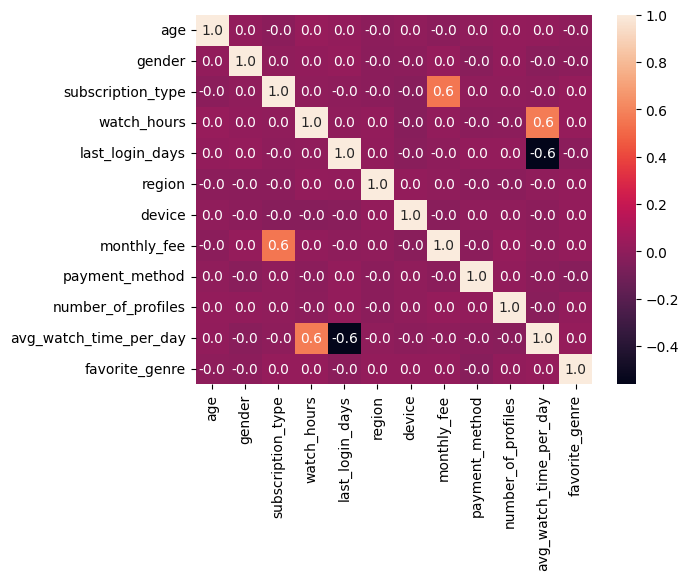

In [203]:
import seaborn as sns

corr_m = X.corr()
sns.heatmap(corr_m, annot=True, fmt='.1f')

определите метрику, которую хотите максимизировать, объясните свой выбор; (F1-Score) - т к он среднее между precision и recall

In [204]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [205]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17)

In [206]:
model_tree = DecisionTreeClassifier(random_state=17)

model_tree.fit(X_train, y_train)
y_pred_tree = model_tree.predict(X_test)

In [207]:
f1_score(y_test, y_pred_tree)

0.9763673193787981

модель явно переобучилось но для красоты хочу это посмотреть через roc_auc_score

In [208]:
y_pred_proba = model_tree.predict_proba(X_test)[:, 1]

f, t, _ = roc_curve(y_test, y_pred_proba)

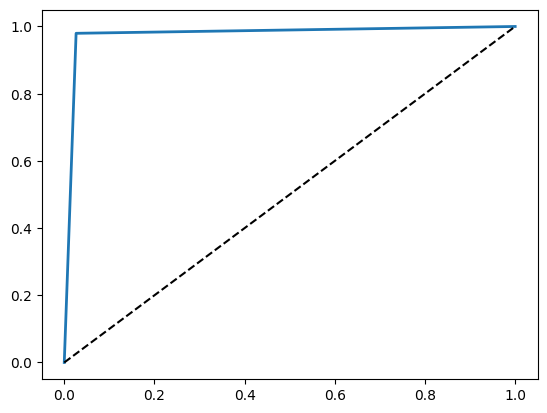

In [209]:
plt.plot(f, t, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')

после этого попробуйте взять из `scikit-learn` класс `BaggingClassifier` (или любой регрессор на основе бустинга, если решаете задачу регрессии) и на основе базовой модели из предыдущего шага обучите его, соберите показатели;

In [223]:
from sklearn.ensemble import BaggingClassifier


bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_depth=5, min_samples_split=10), n_estimators=20,
    max_samples=10, bootstrap=True, n_jobs=-1)

bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

In [224]:
f1_score(y_test, y_pred)

0.8662337662337662

In [225]:
y_pred_proba_bag_clf = bag_clf.predict_proba(X_test)[:, 1]

f, t, _ = roc_curve(y_test, y_pred_proba_bag_clf)

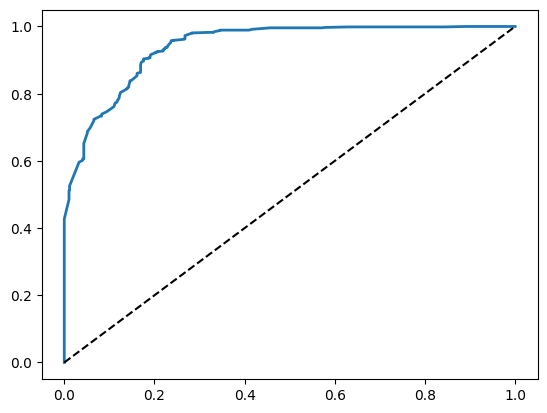

In [226]:
plt.plot(f, t, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')

тут уже интерестнее можно поиграть с параметрами чтобы не было явного переобучения, но уже лучше

возьмите ваш разработанный `BaggingClassifier` (или регрессор на основе бустинга) и обучите его, передав базовую модель, на подготовленных данных;

In [214]:
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.tree import DecisionTreeClassifier
import numpy as np
from copy import deepcopy


class BaggingClassifierCopy:
    def __init__(self, estimator = DecisionTreeClassifier(), n_estimators = 10, 
                 max_samples = 1.0, bootstrap = True, random_state = None):
        self.estimator = estimator #объект
        self.n_estimators = n_estimators #кол-во моделей
        self.max_samples = max_samples #Количество выборок, которые необходимо взять из X для обучения каждого базового оценщика
        self.bootstrap = bootstrap #бутстрап
        self.random_state = random_state


    def bootstrap_sample(self,rand, X):

        n_samples = X.shape[0]

        s_size = int(self.max_samples * n_samples) # используем нужное число объектов

        if self.bootstrap:
            index = rand.choice(n_samples, size= s_size, replace= True) #генерация индексов
        else:
            index = rand.choice(n_samples, size= s_size, replace= False)

        return index


    def fit(self, X, y):
        X, y = check_X_y(X, y, accept_sparse=False) #проверка

        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)

        self.estimators_ = [] # для моделей

        rand = np.random.default_rng(self.random_state)

        for _ in range(self.n_estimators):
            index = self.bootstrap_sample(rand, X)

            X_ = X[index]
            y_ = y[index]

            model = deepcopy(self.estimator) 
            model.fit(X_, y_)
            self.estimators_.append(model)

        return self

        
    def predict(self, X):
        check_is_fitted(self, ['estimators_', 'classes_'])
        X = check_array(X, accept_sparse=False)

        predict_ = np.array(
            [model.predict(X) for model in self.estimators_]
            )
        
        y_pred = np.zeros(X.shape[0], dtype=int)

        for i in range(X.shape[0]):

            vot = predict_[:, i]

            vot_count = np.zeros(self.n_classes_, dtype=int)

            for j in vot:

                id_X = np.where(self.classes_ == j)[0][0]
                vot_count[id_X] += 1

            y_pred[i] = np.argmax(vot_count)

        return self.classes_[y_pred]


    def predict_proba(self, X):
        check_is_fitted(self, ['estimators_', 'classes_'])
        X = check_array(X, accept_sparse=False)


        predict_ = np.array(
            [model.predict_proba(X) for model in self.estimators_]
            )

        return np.mean(predict_, axis=0)

In [227]:
bag_copy = BaggingClassifierCopy(
    DecisionTreeClassifier(max_depth=5, min_samples_split=10), n_estimators=20,
    max_samples=10, bootstrap=True)

bag_copy.fit(X_train, y_train)
y_pred_copy = bag_copy.predict(X_test)

In [228]:
f1_score(y_test, y_pred_copy)

0.9290231904427266

In [229]:
y_pred_proba_copy = bag_copy.predict_proba(X_test)[:, 1]

f1, t1, _ = roc_curve(y_test, y_pred_proba_copy)

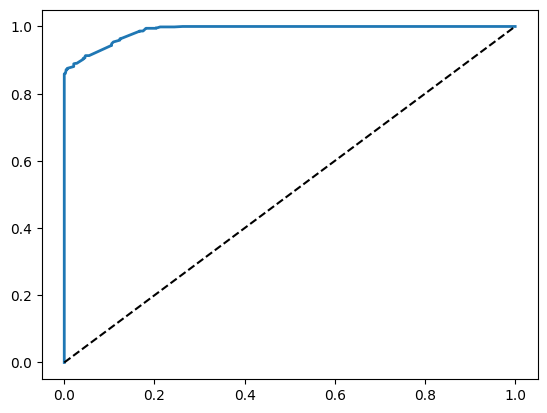

In [230]:
plt.plot(f1, t1, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')

Данные не так сильно отчилаются, но моя модель явно переобучилась, намного сильнее чем стандартный класс BaggingClassifier. так же долго выполняет работу так как нет паралельной работы